### IPL 2022 Capstone Project

The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string

venue : string

stage : string

team1 : string

team2 : string

toss_winner : string

toss_decision : string

first_ings_score : integer

second_ings_score : integer

match_winner : string

won_by : string

margin : integer

player_of_the_match : string

top_scorer : string

highscore : integer

best_bowling : string

best_bowling_fgure : string

gure : string

### Loading the Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [3]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [4]:
print(f"your row is {df.shape[0]} and your column is {df.shape[1]}")

your row is 74 and your column is 20


**Quetion and Answer**

1. Which team won the most matches

In [7]:
match_win=df['match_winner'].value_counts()
match_win

,count
match_winner,
Gujarat,12
Rajasthan,10
Banglore,9
Lucknow,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


Text(0.5, 1.0, 'Most match win by title')

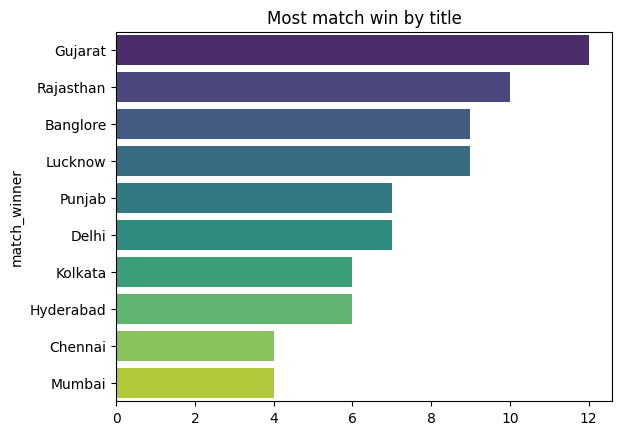

In [14]:
sns.barplot(y=match_win.index,x=match_win.values,palette='viridis')
plt.title('Most match win by title')

2. Toss decision trends

In [17]:
df['toss_decision'].value_counts()

,count
toss_decision,
Field,59
Bat,15


Text(0.5, 1.0, 'Toss Decision')

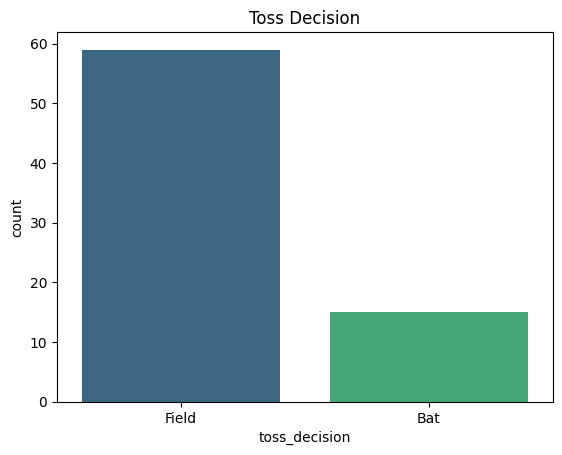

In [18]:
sns.countplot(x='toss_decision',data=df,palette='viridis')
plt.title('Toss Decision')

3. Toss winner VS Match winner

In [25]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
per=(count*100)/df.shape[0]
per.round(2)

np.float64(48.65)

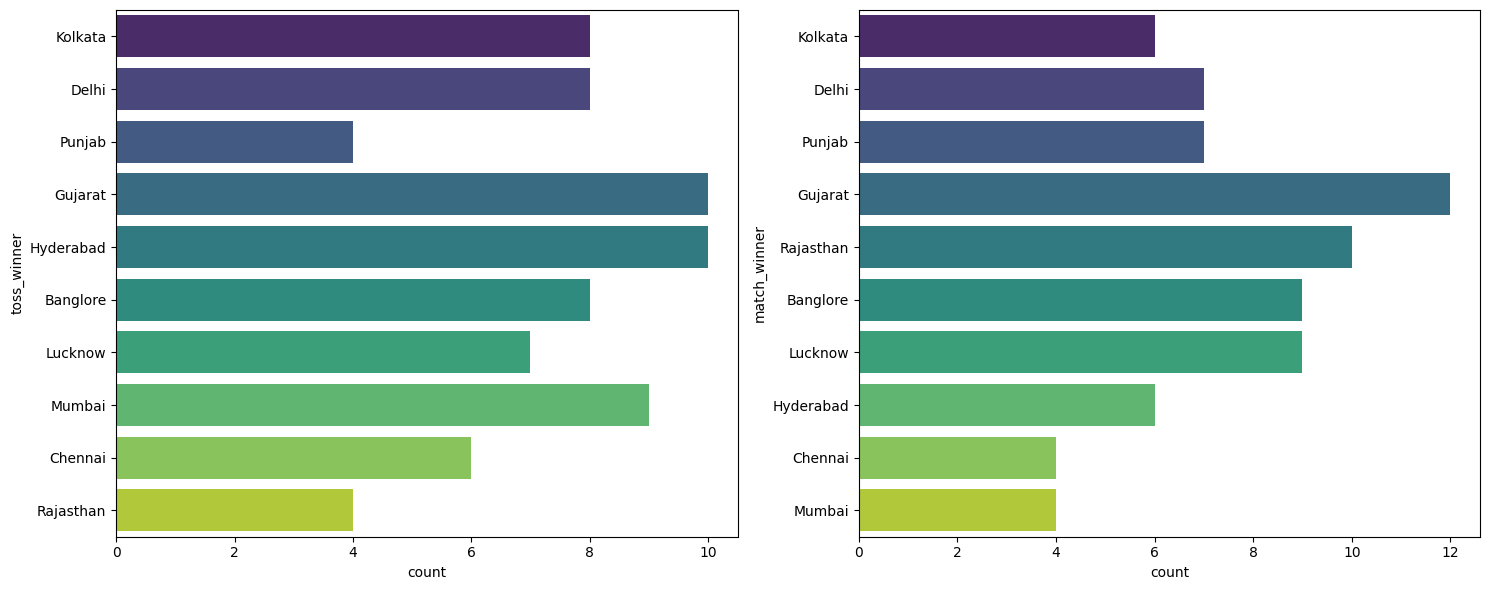

In [44]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
sns.countplot(df['toss_winner'],palette='viridis')
plt.subplot(1,2,2)
sns.countplot(df['match_winner'],palette='viridis')
plt.tight_layout()
plt.show()

4. How do team wins (Runs VS wicket)

<Axes: xlabel='won_by', ylabel='count'>

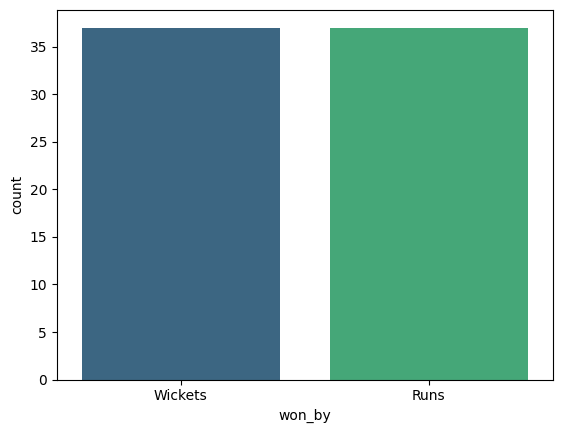

In [31]:
wick=df[df['won_by']=='Wickets']['match_id'].count()
sns.countplot(x='won_by',data=df,palette='viridis')

### Key Player Performance

1. Most Player of the match

In [48]:
count=df['player_of_the_match'].value_counts().head(10)
count

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2
Shubman Gill,2
Avesh Khan,2
Dinesh Karthik,2
Hardik Pandya,2


Text(0.5, 1.0, 'Top 10 player of the match')

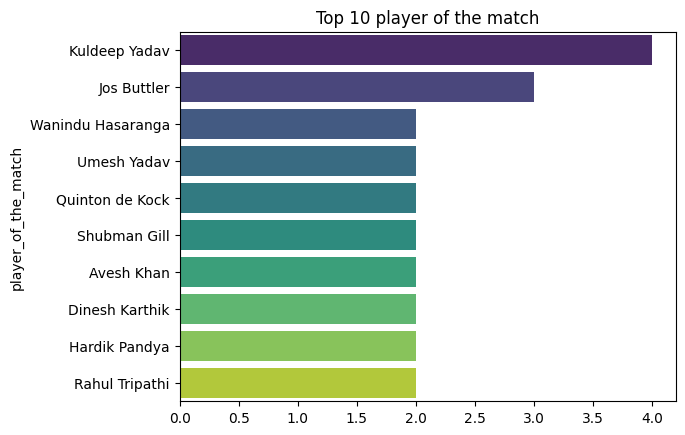

In [51]:
sns.barplot(x=count.values,y=count.index,palette='viridis')
plt.title('Top 10 player of the match')

2. Top Scores

In [53]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
high

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377
KL Rahul,351
Shubman Gill,288
Faf du Plessis,257


Text(0.5, 1.0, 'Top Scorer')

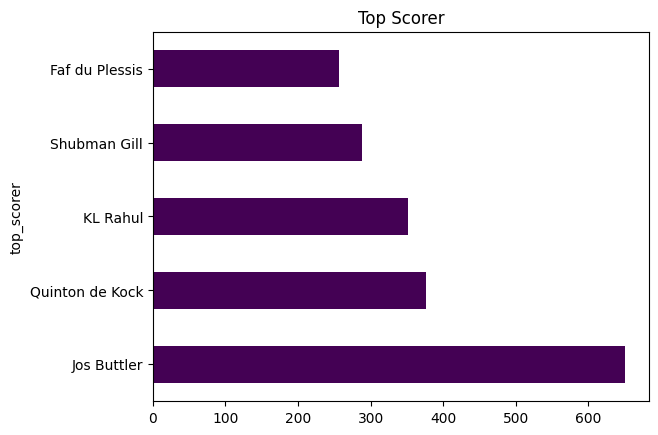

In [59]:
high.plot(kind='barh',colormap='viridis')
plt.title('Top Scorer')

3. Best bowling figures

In [62]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype('int')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [63]:
best_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(5)
best_bowlers

,highest_wickets
best_bowling,
Yuzvendra Chahal,17
Jasprit Bumrah,11
Kuldeep Yadav,11
Rashid Khan,11
Josh Hazlewood,10


Text(0.5, 1.0, 'Best Bowlers')

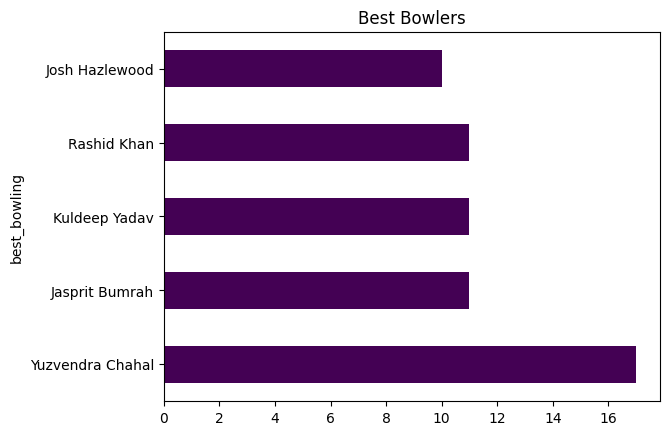

In [64]:
best_bowlers.plot(kind='barh',colormap='viridis')
plt.title('Best Bowlers')

### Venue Analysis

Match played in venues

In [66]:
df['venue'].value_counts()

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


Text(0.5, 1.0, 'Match played in venues')

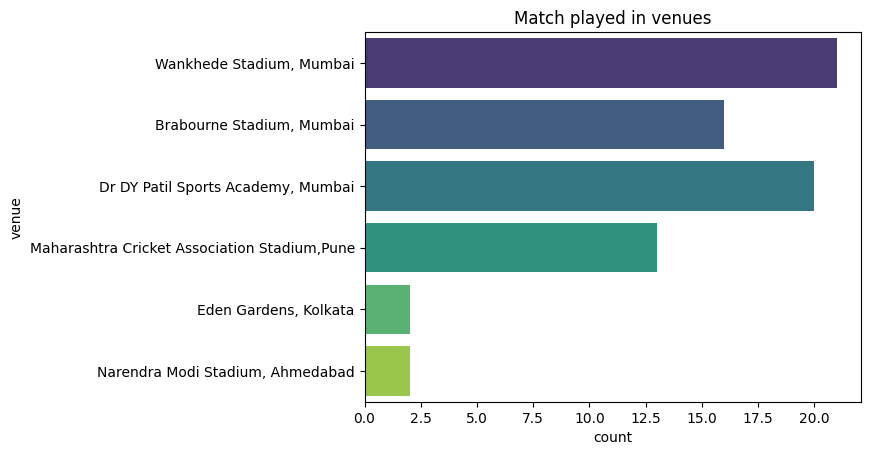

In [71]:
sns.countplot(y='venue',data=df,palette='viridis')
plt.title('Match played in venues')

### Custom Questions & Insights

1. Who won the highest margin by runs?

In [75]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


2. Which player had the highest individual score?

In [80]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


3. Which bowler had the best bowling figures?

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [83]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
